In [11]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors


In [ ]:


path = "OUT_4_NCV_history.txt"

# --- patterns ---
param_pattern = re.compile(r"\{\'paramID\': (\d+), \'LR\': ([0-9.e-]+), \'WD\': ([0-9.e-]+), \'DR\': ([0-9.e-]+), \'epochs\': (\d+)\}")
val_loss_pattern = re.compile(r"E: (\d+) \| Val loss: ([0-9.]+)")
best_loss_pattern = re.compile(r"best_val_loss: ([0-9.]+)")
avg_loss_pattern = re.compile(r"FOLD (\d+) \| ParamID (\d+) \| Avg Val Loss: ([0-9.]+)")

# Outer fold can appear as "OUTER FOLD -0/4-" or "OUTER FOLD -0-"
outer_pattern_1 = re.compile(r"OUTER FOLD -(\d+)/\d+-")
outer_pattern_2 = re.compile(r"OUTER FOLD -(\d+)-")

# Inner fold marker appears as "F-0 | ..."
inner_pattern = re.compile(r"\bF-(\d)\b")

records = []
current_params = None
current_outer = None
current_inner = None
MODEL_NAME = "MultiViewCNN"

with open(path, "r", encoding="utf-8") as f:
	for line in f:
		# --- detect outer fold ---
		if "OUTER FOLD" in line:
			m = outer_pattern_1.search(line) or outer_pattern_2.search(line)
			if m:
				current_outer = int(m.group(1))
			# continue parsing same line for other patterns too (no 'continue')

		# --- detect inner fold (appears on lines like "F-0 | Data loaders ...") ---
		if "F-" in line:
			m = inner_pattern.search(line)
			if m:
				current_inner = int(m.group(1))

		# --- start of a param block ---
		if "paramID" in line and "LR" in line:
			m = param_pattern.search(line)
			if m:
				current_params = {
					"paramID": int(m.group(1)),
					"LR": float(m.group(2)),
					"WD": float(m.group(3)),
					"DR": float(m.group(4)),
					"epochs": int(m.group(5)),
				}

		# --- per-epoch validation loss ---
		m = val_loss_pattern.search(line)
		if m and current_params is not None:
			records.append({
				"Model": MODEL_NAME,
				"outer_fold": current_outer,
				"inner_fold": current_inner,
				**current_params,
				"epoch": int(m.group(1)),
				"val_loss": float(m.group(2)),
				"best_val_loss": None,
				"fold": None,
				"avg_val_loss": None,
			})
			continue

		# --- best validation loss for this param block ---
		m = best_loss_pattern.search(line)
		if m and current_params is not None:
			records.append({
				"Model": MODEL_NAME,
				"outer_fold": current_outer,
				"inner_fold": current_inner,
				**current_params,
				"epoch": None,
				"val_loss": None,
				"best_val_loss": float(m.group(1)),
				"fold": None,
				"avg_val_loss": None,
			})
			continue

		# --- average validation loss summary line (per inner fold) ---
		m = avg_loss_pattern.search(line)
		if m:
			fold, pid, avg = m.groups()
			records.append({
				"Model": MODEL_NAME,
				"outer_fold": current_outer,
				"inner_fold": int(fold),   # explicit inner fold from the summary line
				"paramID": int(pid),
				"LR": None,
				"WD": None,
				"DR": None,
				"epochs": None,
				"epoch": None,
				"val_loss": None,
				"best_val_loss": None,
				"fold": int(fold),         # keep original 'fold' column if you want it too
				"avg_val_loss": float(avg),
			})
			continue

# --- build DataFrame and save once ---
df = pd.DataFrame(records, columns=[
	"Model","outer_fold","inner_fold",
	"paramID","LR","WD","DR","epochs",
	"epoch","val_loss","best_val_loss","fold","avg_val_loss"
])

# Ensure numeric types where appropriate
num_cols = ["outer_fold","inner_fold","paramID","LR","WD","DR","epochs","epoch","val_loss","best_val_loss","fold","avg_val_loss"]
for c in num_cols:
	if c in df.columns:
		df[c] = pd.to_numeric(df[c], errors="coerce")
df
#df.to_csv('OUT_4_NCV_history.csv', index=False)


,Model,outer_fold,inner_fold,paramID,LR,WD,DR,epochs,epoch,val_loss,best_val_loss,fold,avg_val_loss
0,MultiViewCNN,0,0,1,0.0005,0.000100,0.2,10.0,0.0,0.693892,NaN,NaN,NaN
1,MultiViewCNN,0,0,1,0.0005,0.000100,0.2,10.0,1.0,0.684962,NaN,NaN,NaN
2,MultiViewCNN,0,0,1,0.0005,0.000100,0.2,10.0,2.0,0.673770,NaN,NaN,NaN
3,MultiViewCNN,0,0,1,0.0005,0.000100,0.2,10.0,3.0,0.671372,NaN,NaN,NaN
4,MultiViewCNN,0,0,1,0.0005,0.000100,0.2,10.0,4.0,0.665124,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049,MultiViewCNN,3,2,9,0.0008,0.000001,0.2,10.0,7.0,0.547401,NaN,NaN,NaN
1050,MultiViewCNN,3,2,9,0.0008,0.000001,0.2,10.0,8.0,0.520150,NaN,NaN,NaN
1051,MultiViewCNN,3,2,9,0.0008,0.000001,0.2,10.0,9.0,0.509748,NaN,NaN,NaN
1052,MultiViewCNN,3,2,9,0.0008,0.000001,0.2,10.0,NaN,NaN,0.5097,NaN,NaN


In [18]:
df.to_csv('OUT_4_NCV_history.csv', index=False)


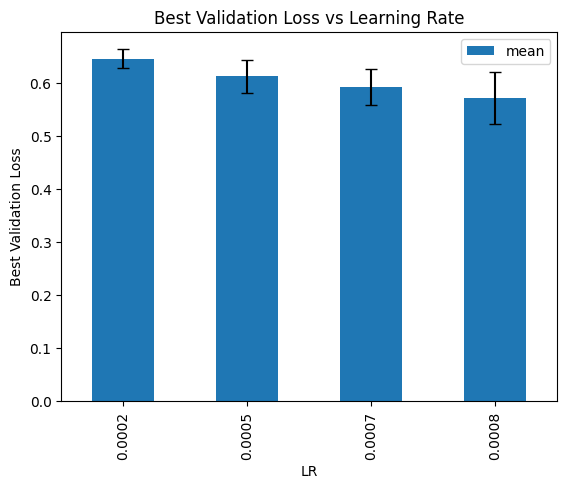

In [26]:
best_df = df[df["best_val_loss"].notna()]

summary = best_df.groupby("LR")["best_val_loss"].agg(["mean","std"])
summary.plot(y="mean", yerr="std", kind="bar", capsize=4)
plt.ylabel("Best Validation Loss")
plt.title("Best Validation Loss vs Learning Rate")
plt.show()


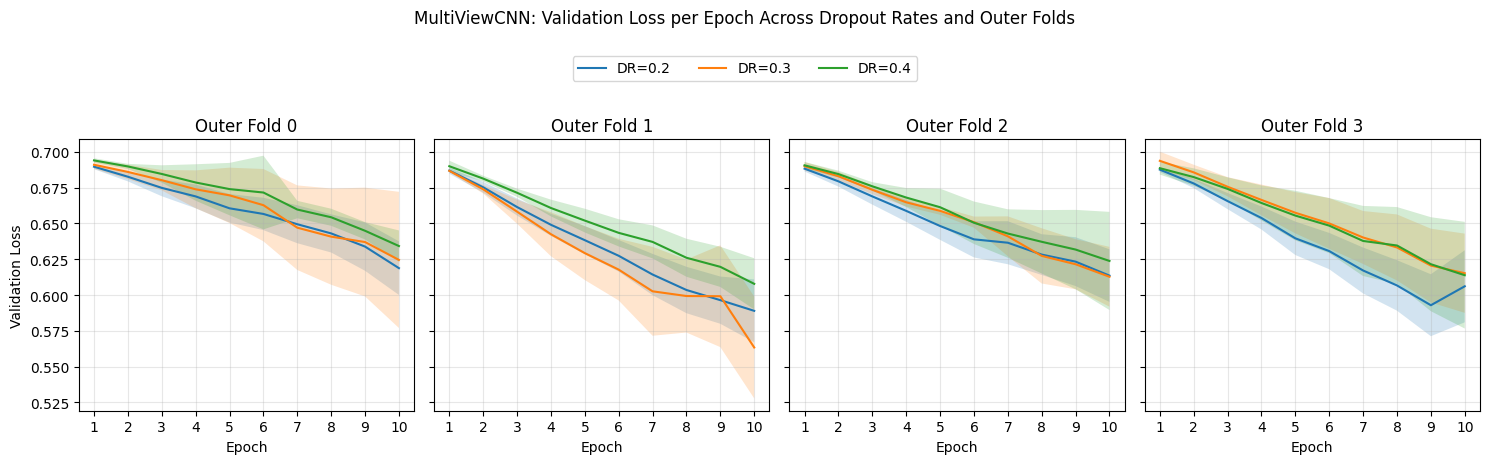

In [ ]:

subset = df[df["val_loss"].notna()].dropna(subset=["outer_fold","inner_fold","DR"])
valid_lrs = [0.0002, 0.0005, 0.0008]

fig, axes = plt.subplots(1, subset["outer_fold"].nunique(),
						 figsize=(15,4), sharey=True, sharex=True)

for outer, ax in zip(sorted(subset["outer_fold"].unique()), axes):
	#d_outer = subset[(subset["outer_fold"]==outer) & (subset["WD"].isin(valid_lrs))]
	d_outer = subset[(subset["outer_fold"]==outer)]

	g = (d_outer.groupby(["LR","epoch"])["val_loss"]
				  .agg(["mean","std","count"]).reset_index())
	g["ci95"] = 1.96*g["std"]/np.sqrt(g["count"])

	for lr, d in g.groupby("DR"):
		ax.plot(d["epoch"]+1, d["mean"], label=f"DR={lr:g}")
		ax.fill_between(d["epoch"]+1, d["mean"]-d["ci95"], d["mean"]+d["ci95"], alpha=0.2)

	ax.set_title(f"Outer Fold {outer}")
	ax.set_xlabel("Epoch")
	ax.grid(alpha=0.3)
	max_epoch = int(d["epoch"].max())+1
	ax.set_xticks(range(1, max_epoch+1))

axes[0].set_ylabel("Validation Loss")

# single legend above all panels
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(valid_lrs), bbox_to_anchor=(0.5, 1.05))

fig.suptitle("MultiViewCNN: Validation Loss per Epoch Across Dropout Rates and Outer Folds", y=1.15)
plt.tight_layout()
plt.show()



In [6]:
#log_path = "outers4_TopParams_training.txt"
log_path = "OUTER_new.csv"
#columns = ["ExpID", "HP_Set", "OuterFold_4" , "Epoch",  "TrainLoss" ,  "TrainAcc",   "ValLoss",   	"ValAcc", 	"LR"]
columns = ["Model", "OuterFold", "HP" , "Epoch",  "TrainLoss" ,  "TrainAcc",   "ValLoss",   	"ValAcc", 'AUC', 'Brier', 'EMA_ValLoss', 'LR', 'NoImprove', 'LrDrop', 'EsTriggered', 'BestValLoss', 'BestEpoch']
df = pd.read_csv(log_path, sep=r'\s*;\s*', engine='python')
print(df.columns)
df = df[columns]
df.columns = df.columns.str.strip()  # clean column names
for col in df.select_dtypes(['object']).columns:
	df[col] = df[col].str.strip()
df = df[columns]
#df["Model"]  = "MultiViewCNN"
#df.to_csv('outers4_TopParams_training.csv', index=False)
df


Index(['08/31/25 - 16:36', 'Model', 'OuterFold', 'HP', 'Epoch', 'TrainLoss',
       'TrainAcc', 'ValLoss', 'ValAcc', 'AUC', 'Brier', 'EMA_ValLoss', 'LR',
       'NoImprove', 'LrDrop', 'EsTriggered', 'BestValLoss', 'BestEpoch'],
      dtype='object')


,Model,OuterFold,HP,Epoch,TrainLoss,TrainAcc,ValLoss,ValAcc,AUC,Brier,EMA_ValLoss,LR,NoImprove,LrDrop,EsTriggered,BestValLoss,BestEpoch
0,MultiViewCNN,1,11,0,0.690989,0.566265,0.688005,0.8,0.88,0.247429,0.688005,0.000200,0,0,0,0.688005,0
1,MultiViewCNN,1,11,1,0.679839,0.650602,0.677264,0.9,0.96,0.242061,0.684783,0.000200,0,0,0,0.677264,1
2,MultiViewCNN,1,11,2,0.673656,0.686747,0.666629,0.7,0.92,0.236789,0.679337,0.000200,0,0,0,0.666629,2
3,MultiViewCNN,1,11,3,0.656335,0.662651,0.663205,0.6,0.88,0.235205,0.674497,0.000200,0,0,0,0.663205,3
4,MultiViewCNN,1,11,4,0.649907,0.638554,0.662507,0.6,0.76,0.235048,0.670900,0.000200,0,0,0,0.662507,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,MultiViewCNN,4,12,41,0.176084,0.939759,0.333724,0.8,1.00,0.114008,0.336458,0.000250,4,0,0,0.271712,37
341,MultiViewCNN,4,12,42,0.166789,0.963855,0.479363,0.8,0.96,0.162835,0.379330,0.000125,5,1,0,0.271712,37
342,MultiViewCNN,4,12,43,0.164255,0.975904,0.403730,0.8,0.96,0.131616,0.386650,0.000125,6,0,0,0.271712,37
343,MultiViewCNN,4,12,44,0.220742,0.915663,0.261183,0.9,1.00,0.076274,0.349010,0.000125,7,0,0,0.271712,37


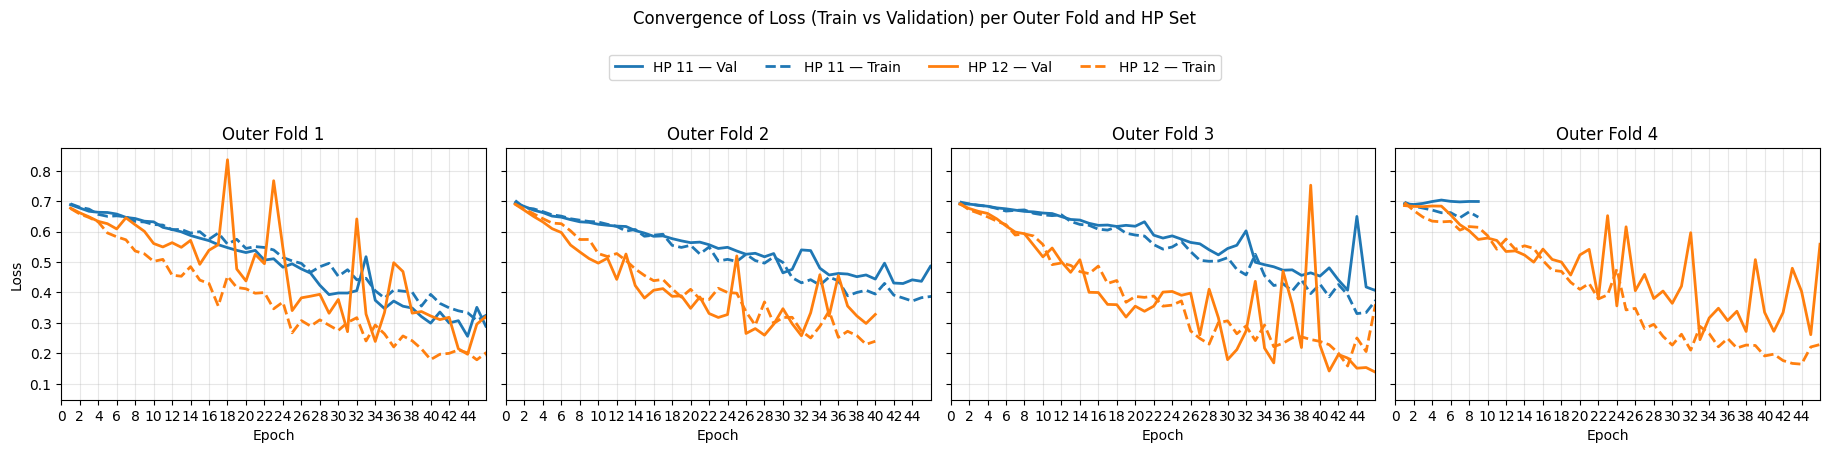

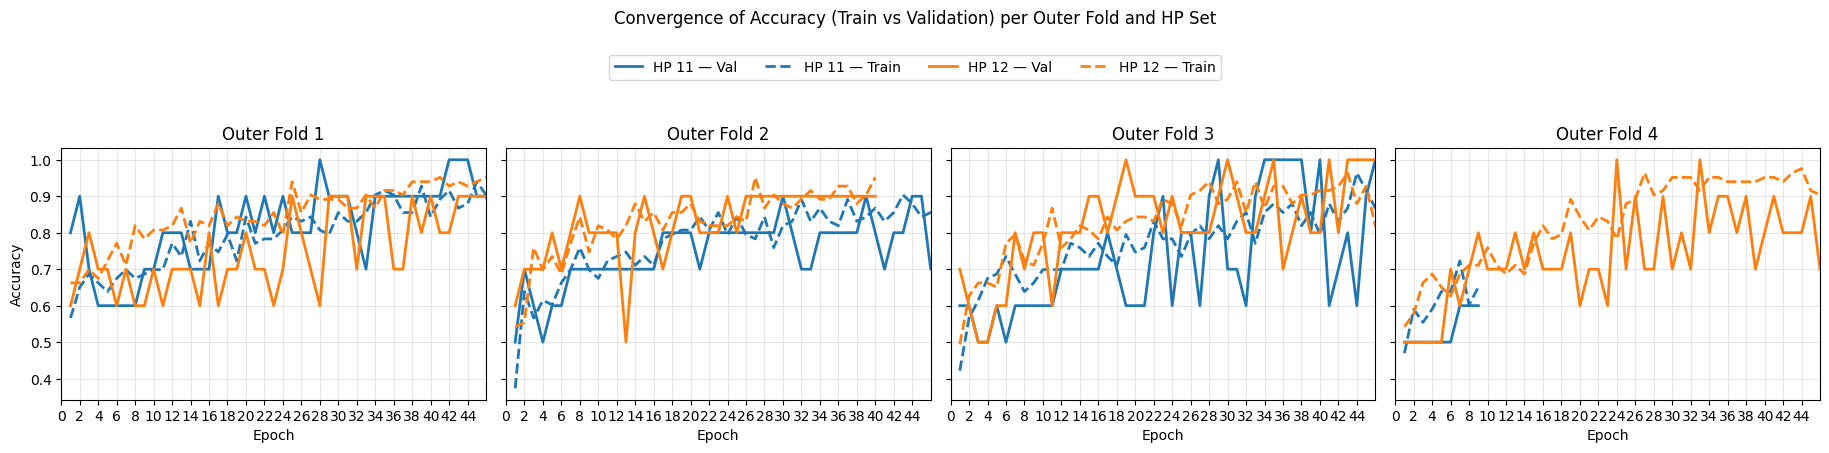

In [7]:


# ---- assume your DataFrame is named df ----
# Optional: restrict to one model
df_plot = df.copy()
# df_plot = df[df["Model"] == "MultiViewCNN"].copy()

# Ensure numeric dtypes
columns = ["Model", "OuterFold", "HP" , "Epoch",  "TrainLoss" ,  "TrainAcc",   "ValLoss",   	"ValAcc", 'AUC', 'Brier', 'EMA_ValLoss', 'LR', 'NoImprove', 'LrDrop', 'EsTriggered', 'BestValLoss', 'BestEpoch']
#num_cols = ["ExpID","HP_Set","OuterFold_4","Epoch","TrainLoss","TrainAcc","ValLoss","ValAcc","LR"]
num_cols = ["OuterFold", "HP" , "Epoch",  "TrainLoss" ,  "TrainAcc",   "ValLoss",   	"ValAcc", 'AUC', 'Brier', 'EMA_ValLoss', 'LR', 'NoImprove', 'LrDrop', 'EsTriggered', 'BestValLoss', 'BestEpoch']


for c in num_cols:
	if c in df_plot.columns:
		df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")

# Aggregate across repeated runs: mean per (outer fold, HP set, epoch)
agg = (df_plot
	   .groupby(["OuterFold","HP","Epoch"], as_index=False)
	   .agg(TrainLoss=("TrainLoss","mean"),
			ValLoss=("ValLoss","mean"),
			TrainAcc=("TrainAcc","mean"),
			ValAcc=("ValAcc","mean")))

outer_folds = sorted(agg["OuterFold"].dropna().unique().tolist())
hp_sets     = sorted(agg["HP"].dropna().unique().tolist())

# Fixed colors per HP set (so Train/Val share the same color)
color_map = {hp: mcolors.to_hex(plt.cm.tab10(i % 10)) for i, hp in enumerate(hp_sets)}



def _integer_epoch_ticks(ax, data):
    if data.empty:
        return

    max_ep = int(data["Epoch"].max())

    # Set ticks to be even numbers from 0 to max_ep
    ax.set_xticks(range(0, max_ep + 1, 2))
    ax.set_xlim(0, max_ep + 1)

# -----------------------------
# FIGURE 1: Loss convergence
# -----------------------------
fig, axes = plt.subplots(1, len(outer_folds), figsize=(4.6*len(outer_folds), 3.8),
						 sharex=True, sharey=True)

if len(outer_folds) == 1:
	axes = [axes]

for ax, of in zip(axes, outer_folds):
	d_of = agg[agg["OuterFold"] == of]
	for hp in hp_sets:
		d = d_of[d_of["HP"] == hp].sort_values("Epoch")
		if d.empty:
			continue
		# Shift epoch to 1..T for display
		x = d["Epoch"].values + 1
		ax.plot(x, d["ValLoss"].values,  label=f"HP {hp} — Val",  color=color_map[hp], linewidth=2)
		ax.plot(x, d["TrainLoss"].values,label=f"HP {hp} — Train",color=color_map[hp], linewidth=2, linestyle="--")
	ax.set_title(f"Outer Fold {of}")
	ax.set_xlabel("Epoch")
	ax.grid(alpha=0.3)
	_integer_epoch_ticks(ax, d_of)

axes[0].set_ylabel("Loss")

# Single legend above all panels, condensed
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 6), bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Convergence of Loss (Train vs Validation) per Outer Fold and HP Set", y=1.18, fontsize=12)
plt.tight_layout()
plt.show()

# --------------------------------
# FIGURE 2: Accuracy convergence
# --------------------------------
fig, axes = plt.subplots(1, len(outer_folds), figsize=(4.6*len(outer_folds), 3.8),
						 sharex=True, sharey=True)

if len(outer_folds) == 1:
	axes = [axes]

for ax, of in zip(axes, outer_folds):
	d_of = agg[agg["OuterFold"] == of]
	for hp in hp_sets:
		d = d_of[d_of["HP"] == hp].sort_values("Epoch")
		if d.empty:
			continue
		x = d["Epoch"].values + 1
		ax.plot(x, d["ValAcc"].values,   label=f"HP {hp} — Val",  color=color_map[hp], linewidth=2)
		ax.plot(x, d["TrainAcc"].values, label=f"HP {hp} — Train",color=color_map[hp], linewidth=2, linestyle="--")
	ax.set_title(f"Outer Fold {of}")
	ax.set_xlabel("Epoch")
	ax.grid(alpha=0.3)
	_integer_epoch_ticks(ax, d_of)

axes[0].set_ylabel("Accuracy")

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 6), bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Convergence of Accuracy (Train vs Validation) per Outer Fold and HP Set", y=1.18, fontsize=12)
plt.tight_layout()
plt.show()


In [12]:


import pandas as pd
#log_path = "outers4_TopParams_training.txt"
log_path = "characteristics.csv"
df = pd.read_csv(log_path, sep=r'\s*,\s*', engine='python')
print(df.columns)
#df["Model"]  = "MultiViewCNN"
#df.to_csv('outers4_TopParams_training.csv', index=False)
df


Index(['Label', 'PatientID', 'Age', 'Gender'], dtype='object')


,Label,PatientID,Age,Gender
0,1,AD 12191953,51,1
1,1,AG 11370442,68,1
2,1,AMH 36922300,85,1
3,1,AMS 22722383,75,1
4,1,APH 3516218,67,1
...,...,...,...,...
162,0,VM 50032811,93,1
163,0,VMI 00101342,37,1
164,0,WL 260776,64,1
165,0,YPC 50401036,90,0


In [ ]:

# Functions for mean±std string
def mean_std(series):
    return f"{series.mean():.2f} ± {series.std():.2f}"

# Overall stats
overall_age = mean_std(df["Age"])
tts_age = mean_std(df.loc[df["Label"]==1, "Age"])
normal_age = mean_std(df.loc[df["Label"]==0, "Age"])

# By gender age stats
overall_m_age = mean_std(df.loc[df["Gender"]==0, "Age"])
overall_f_age = mean_std(df.loc[df["Gender"]==1, "Age"])
tts_m_age = mean_std(df.loc[(df["Label"]==1)&(df["Gender"]==0), "Age"])
tts_f_age = mean_std(df.loc[(df["Label"]==1)&(df["Gender"]==1), "Age"])
normal_m_age = mean_std(df.loc[(df["Label"]==0)&(df["Gender"]==0), "Age"])
normal_f_age = mean_std(df.loc[(df["Label"]==0)&(df["Gender"]==1), "Age"])

# Counts
def counts(col):
    return df[col].value_counts()

gender_counts_overall = df["Gender"].value_counts().to_dict()
gender_counts_tts = df.loc[df["Label"]==1,"Gender"].value_counts().to_dict()
gender_counts_normal = df.loc[df["Label"]==0,"Gender"].value_counts().to_dict()

overall_age
tts_age
normal_age
overall_m_age
overall_f_age
tts_m_age
tts_f_age
normal_m_age
normal_f_age
#gender_counts_overall
#gender_counts_tts
#gender_counts_normal

print(F"overall_age: {overall_age}, tts_age: {tts_age}, normal_age: {normal_age}")
print(F"overall_female_age: {overall_f_age}, overall_male_age: {overall_m_age}")
print(F"tts_female_age: {tts_f_age}, tts_male_age: {tts_m_age}")
print(F"normal_female_age: {normal_f_age}, normal_male_age: {normal_m_age}, ")
#gender_counts_overall
#gender_counts_tts
#gender_counts_normal
print(f"gender_counts_overall: {gender_counts_overall}, gender_counts_tts: {gender_counts_tts}, gender_counts_normal: {gender_counts_normal}")


overall_age: 70.90 ± 15.59, tts_age: 75.89 ± 13.08, normal_age: 64.93 ± 16.31
overall_female_age: 71.58 ± 15.41, overall_male_age: 67.94 ± 16.26
tts_female_age: 75.83 ± 12.99, tts_male_age: 76.50 ± 14.90
normal_female_age: 64.92 ± 16.62, normal_male_age: 64.96 ± 15.93, 
gender_counts_overall: {1: 136, 0: 31}, gender_counts_tts: {1: 83, 0: 8}, gender_counts_normal: {1: 53, 0: 23}
